# Model 2: Duration Band Prediction

**Objective:** Predict how long a Bengaluru traffic disruption will last at event-creation time.

**Target:** `duration_band`

- `short`: less than 1 hour
- `medium`: 1 to 4 hours
- `long`: more than 4 hours

**Primary metric:** Macro-F1, because the rare `long` class matters operationally.

This notebook uses the feature-engineered file `outputs/model_ready_duration_band.csv`. It also includes an optional section for adding Model 1 closure probabilities only when an aligned prediction file exists.

## 0. Install Dependencies

Run this cell first if your environment does not already have the ML stack installed. In Google Colab, run it once and then continue with the rest of the notebook.

## 1. Imports and Project Paths

This cell resolves the project root automatically, so the notebook works from Jupyter, VS Code, or Colab after the repo is mounted/copied.

In [1]:
from pathlib import Path
import json
import os
import warnings

mpl_cache_dir = Path.cwd().resolve() / '.cache' / 'matplotlib'
mpl_cache_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(mpl_cache_dir))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as exc:
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = exc

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 80)

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd, *cwd.parents] if (p / 'outputs').exists()), cwd)
DATA_PATH = r'D:\Python\Gridlock\Phase 2\model2_duration_handoff.csv'
MODELS_DIR = PROJECT_ROOT / 'models'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'

print('Project root:', PROJECT_ROOT)
print('Data path:', DATA_PATH)
print('XGBoost available:', XGBOOST_AVAILABLE)
if not XGBOOST_AVAILABLE:
    print('XGBoost import issue:', XGBOOST_IMPORT_ERROR)

Project root: D:\Python\Gridlock\Phase 2\theme 2
Data path: D:\Python\Gridlock\Phase 2\model2_duration_handoff.csv
XGBoost available: True


## 2. Load Duration-Band Dataset

The feature engineering notebook already removed invalid durations and created the target. This notebook treats that file as the modeling contract.

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (3498, 224)


,id,_source_row,prediction_datetime,start_datetime,latitude,longitude,lat_round_3,lon_round_3,lat_round_2,lon_round_2,distance_to_city_center_km,distance_to_city_center_log1p,start_hour,start_dayofweek,start_month_number,start_weekofyear,is_weekend,is_morning_peak,is_evening_peak,is_peak_hour,is_night,hour_sin,hour_cos,day_sin,day_cos,report_lag_minutes_clipped,report_lag_hours_clipped,report_lag_log1p,description_missing,text_length,description_char_length,description_word_count,description_word_count_log1p,has_non_ascii_text,has_kannada_text,has_accident_word,has_breakdown_word,has_water_word,has_construction_word,has_event_word,has_blocked_word,has_jam_word,has_vip_word,has_location_hint_word,has_lane_word,has_full_blockage_phrase,has_partial_blockage_phrase,has_diversion_word,has_severity_word,has_tree_fall_word,closure_text_signal_count,has_any_closure_text_signal,is_planned_event,is_public_or_vip_event,is_breakdown_event,is_accident_event,is_weather_or_visibility_event,is_road_condition_event,has_vehicle_type,is_truck,...,past_duration_rate_very_long_junction,past_duration_count_police_station,past_duration_q25_police_station,past_duration_median_police_station,past_duration_q75_police_station,past_duration_rate_short_police_station,past_duration_rate_medium_police_station,past_duration_rate_long_police_station,past_duration_rate_very_long_police_station,past_duration_count_location_grid,past_duration_q25_location_grid,past_duration_median_location_grid,past_duration_q75_location_grid,past_duration_rate_short_location_grid,past_duration_rate_medium_location_grid,past_duration_rate_long_location_grid,past_duration_rate_very_long_location_grid,past_duration_count_event_cause_corridor,past_duration_q25_event_cause_corridor,past_duration_median_event_cause_corridor,past_duration_q75_event_cause_corridor,past_duration_rate_short_event_cause_corridor,past_duration_rate_medium_event_cause_corridor,past_duration_rate_long_event_cause_corridor,past_duration_rate_very_long_event_cause_corridor,log1p_past_count_event_cause,log1p_past_count_corridor,log1p_past_count_zone,log1p_past_count_junction,log1p_past_count_police_station,log1p_past_count_location_grid,log1p_past_count_event_cause_corridor,log1p_past_closure_global_count,log1p_past_closure_count_event_cause,log1p_past_closure_count_corridor,log1p_past_closure_count_zone,log1p_past_closure_count_junction,log1p_past_closure_count_police_station,log1p_past_closure_count_location_grid,log1p_past_closure_count_event_cause_corridor,log1p_past_duration_global_count,log1p_past_duration_count_event_cause,log1p_past_duration_count_corridor,log1p_past_duration_count_zone,log1p_past_duration_count_junction,log1p_past_duration_count_police_station,log1p_past_duration_count_location_grid,log1p_past_duration_count_event_cause_corridor,log1p_past_count_7d_event_cause,log1p_past_count_30d_event_cause,log1p_past_count_7d_corridor,log1p_past_count_30d_corridor,log1p_past_count_7d_event_cause_corridor,log1p_past_count_30d_event_cause_corridor,log1p_past_count_7d_location_grid_coarse,log1p_past_count_30d_location_grid_coarse,duration_minutes_raw,duration_band,road_closure_probability,road_closure_probability_is_history_fallback
0,FKID005760,5760,2023-11-09 19:27:19.694644+00:00,2023-11-09 19:24:48.154000+00:00,12.966897,77.610555,12.967,77.611,12.97,77.61,1.806229,1.031842,0.0,4.0,11.0,45,0,0,0,0,1,0.000000,1.000000e+00,-0.433884,-0.900969,2.525677,0.042095,1.260073,0,129,35,7,2.079442,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.25,0,NaN,NaN,NaN,0.25,0.25,0.25,0.25,0,NaN,NaN,NaN,0.25,0.25,0.25,0.25,0,NaN,NaN,NaN,0.25,0.25,0.25,0.25,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,203.828038,medium,1.000000,1
1,FKID005197,5197,2023-11-09 20:53:11.012768+00:00,2023-11-09 20:51:36.296000+00:00,12.921773

## 3. Basic Data Checks

These checks help confirm that the target exists, the class balance is understood, and the feature matrix is usable.

In [3]:
target_col = 'duration_band'
assert target_col in df.columns, f'Missing target column: {target_col}'

print('Rows:', len(df))
print('Columns:', len(df.columns))
print('\nTarget counts:')
display(df[target_col].value_counts(dropna=False).to_frame('count'))
print('\nTarget percentages:')
display((df[target_col].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame('percent'))

missing_target = df[target_col].isna().sum()
duplicate_columns = df.columns[df.columns.duplicated()].tolist()
print('\nMissing target rows:', missing_target)
print('Duplicate columns:', duplicate_columns if duplicate_columns else 'None')

Rows: 3498
Columns: 224

Target counts:


,count
duration_band,
short,1579
medium,903
very_long,736
long,280



Target percentages:


,percent
duration_band,
short,45.14
medium,25.81
very_long,21.04
long,8.00



Missing target rows: 0
Duplicate columns: None


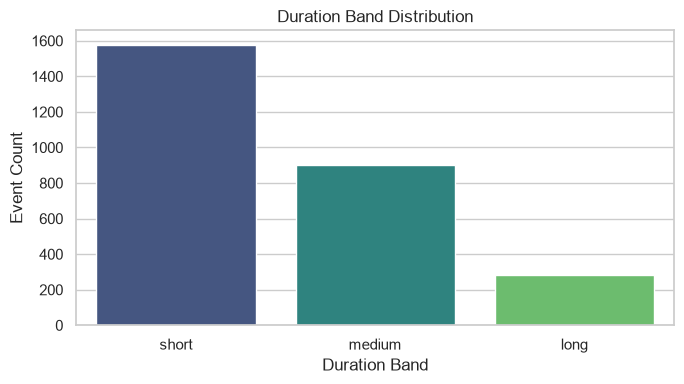

In [4]:
plt.figure(figsize=(7, 4))
order = ['short', 'medium', 'long']
sns.countplot(data=df, x=target_col, order=[c for c in order if c in df[target_col].unique()], palette='viridis')
plt.title('Duration Band Distribution')
plt.xlabel('Duration Band')
plt.ylabel('Event Count')
plt.tight_layout()
plt.show()

## 4. Optional: Add Model 1 Closure Probability

Model 2 should eventually use Model 1's `P(road_closure)` as a stacked feature. That is only safe when the Model 1 prediction file has a reliable join key or exactly matches this dataset row-for-row.

The current repository output `outputs/test_predictions_with_percentages.csv` is not aligned to all duration rows, so this cell will skip it unless a safe aligned file exists.

Supported aligned files:

- `outputs/model1_aligned_probabilities.csv` with either:
  - same number of rows as this dataset, or
  - a join key column shared with this dataset

In [5]:
aligned_model1_path = OUTPUTS_DIR / 'model1_aligned_probabilities.csv'
model1_feature_name = 'model1_closure_probability'

if aligned_model1_path.exists():
    model1_df = pd.read_csv(aligned_model1_path)
    probability_candidates = [
        'model1_closure_probability',
        'prediction_probability',
        'closure_probability',
        'p_road_closure',
    ]
    probability_col = next((c for c in probability_candidates if c in model1_df.columns), None)
    shared_keys = [c for c in ['event_id', 'id', 'row_id', 'source_index'] if c in df.columns and c in model1_df.columns]

    if probability_col is None:
        print('Aligned Model 1 file found, but no probability column was recognized. Skipping stacked feature.')
    elif shared_keys:
        key = shared_keys[0]
        before_cols = set(df.columns)
        df = df.merge(model1_df[[key, probability_col]], on=key, how='left')
        df = df.rename(columns={probability_col: model1_feature_name})
        df[model1_feature_name] = df[model1_feature_name].fillna(df[model1_feature_name].median())
        print(f'Added Model 1 probability using join key: {key}')
    elif len(model1_df) == len(df):
        df[model1_feature_name] = model1_df[probability_col].values
        print('Added Model 1 probability by exact row alignment.')
    else:
        print('Aligned Model 1 file row count does not match and no shared key exists. Skipping stacked feature.')
else:
    print('No aligned Model 1 probability file found. Training Model 2 without stacked closure probability.')

print('Current shape:', df.shape)

No aligned Model 1 probability file found. Training Model 2 without stacked closure probability.
Current shape: (3498, 224)


## 5. Feature Matrix and Target Encoding

We exclude the target and any obvious future/leakage columns if they appear. The feature-engineered CSV is already mostly numeric and one-hot encoded.

In [6]:
leakage_or_non_feature_cols = [
    target_col,
    'duration_minutes',
    'duration_minutes_raw',
    'resolved_datetime',
    'closed_datetime',
    'modified_datetime',
    'status',
    'closed_by_id',
    'resolved_by_id',
]

exclude_cols = [c for c in leakage_or_non_feature_cols if c in df.columns]
feature_cols = [c for c in df.columns if c not in exclude_cols]

model_df = df.dropna(subset=[target_col]).copy()
X = model_df[feature_cols].copy()
y_raw = model_df[target_col].astype(str).str.lower().str.strip()

# Coerce all features to numeric. Any accidental non-numeric column becomes NaN and is imputed below.
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

nan_counts = X.isna().sum()
cols_with_nan = nan_counts[nan_counts > 0]
if len(cols_with_nan):
    print('Columns with missing numeric values:', len(cols_with_nan))
    display(cols_with_nan.sort_values(ascending=False).head(20).to_frame('missing_count'))

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True)).fillna(0)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
inverse_label_mapping = {int(v): k for k, v in label_mapping.items()}

print('Feature matrix:', X.shape)
print('Label mapping:', label_mapping)
print('Feature dtypes:')
print(X.dtypes.value_counts())

Columns with missing numeric values: 55


,missing_count
id,3498
prediction_datetime,3498
start_datetime,3498
event_type,3498
event_cause,3498
veh_type,3498
corridor,3498
police_station,3498
zone,3498
junction,3498


Feature matrix: (3498, 222)
Label mapping: {'long': np.int64(0), 'medium': np.int64(1), 'short': np.int64(2), 'very_long': np.int64(3)}
Feature dtypes:
float64    146
int64       76
Name: count, dtype: int64


## 6. Train / Validation / Test Split

The model-ready file does not keep the original timestamp, so we use stratified splitting to preserve the rare `long` class in each split. If you later add a true event timestamp back to this file, this section can be switched to chronological splitting.

In [7]:
RANDOM_STATE = 42

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print('Train:', X_train.shape, pd.Series(y_train).map(inverse_label_mapping).value_counts().to_dict())
print('Val:  ', X_val.shape, pd.Series(y_val).map(inverse_label_mapping).value_counts().to_dict())
print('Test: ', X_test.shape, pd.Series(y_test).map(inverse_label_mapping).value_counts().to_dict())

Train: (2448, 222) {'short': 1105, 'medium': 632, 'very_long': 515, 'long': 196}
Val:   (525, 222) {'short': 237, 'medium': 135, 'very_long': 111, 'long': 42}
Test:  (525, 222) {'short': 237, 'medium': 136, 'very_long': 110, 'long': 42}


In [8]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score

cat_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    iterations=800,
    learning_rate=0.04,
    depth=5,
    l2_leaf_reg=5,
    random_seed=42,
    verbose=100,
    auto_class_weights='Balanced'
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

cat_val_pred = cat_model.predict(X_val).astype(int).ravel()

print("CatBoost - Validation")
print("Macro-F1:", f1_score(y_val, cat_val_pred, average='macro'))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, cat_val_pred))
print(classification_report(y_val, cat_val_pred, target_names=label_encoder.classes_))

0:	learn: 0.4904068	test: 0.4976662	best: 0.4976662 (0)	total: 215ms	remaining: 2m 51s
100:	learn: 0.6222834	test: 0.4693557	best: 0.4976662 (0)	total: 7.04s	remaining: 48.7s
200:	learn: 0.7066594	test: 0.4814112	best: 0.4983315 (127)	total: 15.3s	remaining: 45.7s
300:	learn: 0.7474210	test: 0.4895005	best: 0.4983315 (127)	total: 21.4s	remaining: 35.4s
400:	learn: 0.7895964	test: 0.4872927	best: 0.5046024 (317)	total: 27.9s	remaining: 27.7s
500:	learn: 0.8216704	test: 0.4893401	best: 0.5046024 (317)	total: 34.8s	remaining: 20.8s
600:	learn: 0.8527615	test: 0.4740716	best: 0.5046024 (317)	total: 43.1s	remaining: 14.3s
700:	learn: 0.8702990	test: 0.4733780	best: 0.5046024 (317)	total: 49s	remaining: 6.92s
799:	learn: 0.8884935	test: 0.4900057	best: 0.5046024 (317)	total: 56.1s	remaining: 0us

bestTest = 0.5046023658
bestIteration = 317

Shrink model to first 318 iterations.
CatBoost - Validation
Macro-F1: 0.4909348741807512
Balanced Accuracy: 0.5256814228333215
              precision   

## 7. Baseline Model: Random Forest

This gives a sturdy comparison point before the main gradient-boosted model.

In [9]:
baseline_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

baseline_model.fit(X_train, y_train)
baseline_val_pred = baseline_model.predict(X_val)
baseline_val_proba = baseline_model.predict_proba(X_val)

baseline_macro_f1 = f1_score(y_val, baseline_val_pred, average='macro')
baseline_bal_acc = balanced_accuracy_score(y_val, baseline_val_pred)

print('Baseline Random Forest - Validation')
print('Macro-F1:', round(baseline_macro_f1, 4))
print('Balanced Accuracy:', round(baseline_bal_acc, 4))
print('\nClassification Report:')
print(classification_report(y_val, baseline_val_pred, target_names=label_encoder.classes_))

Baseline Random Forest - Validation
Macro-F1: 0.4933
Balanced Accuracy: 0.5243

Classification Report:
              precision    recall  f1-score   support

        long       0.71      0.29      0.41        42
      medium       0.38      0.12      0.18       135
       short       0.65      0.75      0.69       237
   very_long       0.55      0.95      0.69       111

    accuracy                           0.59       525
   macro avg       0.57      0.52      0.49       525
weighted avg       0.56      0.59      0.54       525



## 8. Main Model: XGBoost Multi-Class Classifier

XGBoost is used for consistency with Model 1. If XGBoost is unavailable, this notebook falls back to the Random Forest baseline so the rest of the evaluation still runs.

In [10]:
train_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)
val_sample_weight = compute_sample_weight(class_weight='balanced', y=y_val)

if XGBOOST_AVAILABLE:
    main_model = XGBClassifier(
        objective='multi:softprob',
        num_class=len(label_encoder.classes_),
        eval_metric='mlogloss',
        n_estimators=700,
        max_depth=4,
        learning_rate=0.035,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        reg_lambda=2.0,
        reg_alpha=0.1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method='hist',
    )

    main_model.fit(
        X_train,
        y_train,
        sample_weight=train_sample_weight,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    model_name = 'XGBoost'
else:
    main_model = baseline_model
    model_name = 'RandomForestFallback'

val_pred = main_model.predict(X_val)
val_proba = main_model.predict_proba(X_val)

val_macro_f1 = f1_score(y_val, val_pred, average='macro')
val_bal_acc = balanced_accuracy_score(y_val, val_pred)

print(f'{model_name} - Validation')
print('Macro-F1:', round(val_macro_f1, 4))
print('Balanced Accuracy:', round(val_bal_acc, 4))
print('\nClassification Report:')
print(classification_report(y_val, val_pred, target_names=label_encoder.classes_))

XGBoost - Validation
Macro-F1: 0.5242
Balanced Accuracy: 0.5359

Classification Report:
              precision    recall  f1-score   support

        long       0.53      0.38      0.44        42
      medium       0.40      0.30      0.34       135
       short       0.65      0.63      0.64       237
   very_long       0.56      0.84      0.67       111

    accuracy                           0.57       525
   macro avg       0.54      0.54      0.52       525
weighted avg       0.56      0.57      0.55       525



## 9. Validation Confusion Matrix

Read this matrix row-wise: each row is the actual class, each column is the predicted class.

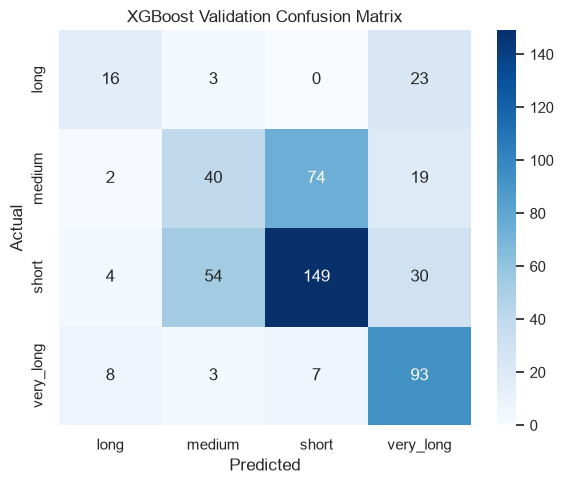

,long,medium,short,very_long
long,16,3,0,23
medium,2,40,74,19
short,4,54,149,30
very_long,8,3,7,93


In [11]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    return cm_df

val_cm_df = plot_confusion(y_val, val_pred, f'{model_name} Validation Confusion Matrix')
display(val_cm_df)

## 10. Final Test Evaluation

Only run this after you are happy with validation performance. This gives the held-out score for the final report.

XGBoost - Test Set
Accuracy: 0.6095
Balanced Accuracy: 0.5919
Macro-F1: 0.5795
Weighted-F1: 0.5967

Classification Report:
              precision    recall  f1-score   support

        long       0.56      0.55      0.55        42
      medium       0.41      0.30      0.35       136
       short       0.67      0.70      0.68       237
   very_long       0.66      0.82      0.73       110

    accuracy                           0.61       525
   macro avg       0.58      0.59      0.58       525
weighted avg       0.59      0.61      0.60       525



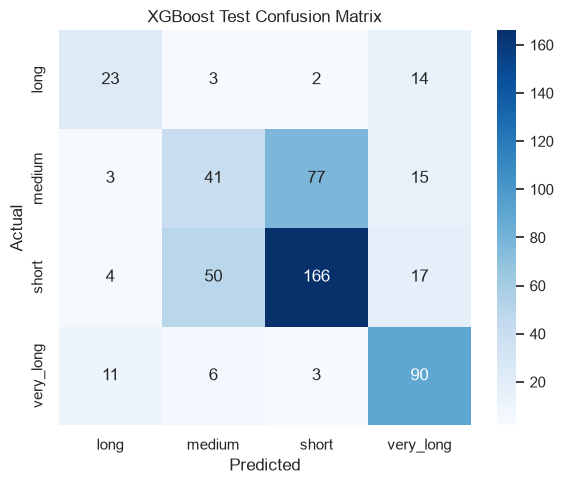

,long,medium,short,very_long
long,23,3,2,14
medium,3,41,77,15
short,4,50,166,17
very_long,11,6,3,90


In [12]:
test_pred = main_model.predict(X_test)
test_proba = main_model.predict_proba(X_test)

test_accuracy = accuracy_score(y_test, test_pred)
test_bal_acc = balanced_accuracy_score(y_test, test_pred)
test_macro_f1 = f1_score(y_test, test_pred, average='macro')
test_weighted_f1 = f1_score(y_test, test_pred, average='weighted')

print(f'{model_name} - Test Set')
print('Accuracy:', round(test_accuracy, 4))
print('Balanced Accuracy:', round(test_bal_acc, 4))
print('Macro-F1:', round(test_macro_f1, 4))
print('Weighted-F1:', round(test_weighted_f1, 4))
print('\nClassification Report:')
print(classification_report(y_test, test_pred, target_names=label_encoder.classes_))

test_cm_df = plot_confusion(y_test, test_pred, f'{model_name} Test Confusion Matrix')
display(test_cm_df)

## 11. Per-Class Recall Check

For operations, recall on `long` is especially important because missing long disruptions is costly.

In [13]:
precision, recall, f1, support = precision_recall_fscore_support(y_test, test_pred, zero_division=0)
per_class_metrics = pd.DataFrame({
    'class': label_encoder.classes_,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'support': support,
}).sort_values('class')

display(per_class_metrics)

if 'long' in label_encoder.classes_:
    long_idx = int(np.where(label_encoder.classes_ == 'long')[0][0])
    print('Long-class recall:', round(float(recall[long_idx]), 4))

,class,precision,recall,f1,support
0,long,0.560976,0.547619,0.554217,42
1,medium,0.410000,0.301471,0.347458,136
2,short,0.669355,0.700422,0.684536,237
3,very_long,0.661765,0.818182,0.731707,110


Long-class recall: 0.5476


## 12. Prediction Probability Output

This creates an interpretable table with actual label, predicted label, confidence, and one probability column per duration band.

In [14]:
proba_cols = [f'prob_{label}' for label in label_encoder.classes_]

predictions_df = pd.DataFrame(test_proba, columns=proba_cols, index=X_test.index)
predictions_df.insert(0, 'actual_duration_band', label_encoder.inverse_transform(y_test))
predictions_df.insert(1, 'predicted_duration_band', label_encoder.inverse_transform(test_pred))
predictions_df.insert(2, 'prediction_confidence', test_proba.max(axis=1))
predictions_df.insert(3, 'source_row_index', X_test.index)

predictions_df = predictions_df.sort_index().reset_index(drop=True)
display(predictions_df.head(20))

,actual_duration_band,predicted_duration_band,prediction_confidence,source_row_index,prob_long,prob_medium,prob_short,prob_very_long
0,very_long,very_long,0.848886,18,0.001868,0.054459,0.094787,0.848886
1,short,medium,0.790808,22,0.005339,0.790808,0.122979,0.080874
2,short,medium,0.701482,32,0.004210,0.701482,0.282644,0.011664
3,medium,medium,0.617051,36,0.012343,0.617051,0.342717,0.027889
4,short,short,0.794647,45,0.017754,0.136499,0.794647,0.051101
5,short,short,0.626317,46,0.012939,0.304912,0.626317,0.055831
6,medium,short,0.430549,48,0.014909,0.235935,0.430549,0.318607
7,very_long,long,0.689305,59,0.689305,0.004407,0.016793,0.289495
8,very_long,very_long,0.841437,71,0.025293,0.075660,0.057611,0.841437
9,short,short,0.898741,76,0.018235,0.068722,0.898741,0.014302


## 13. Feature Importance

For XGBoost, this uses model gain/importance. For the fallback Random Forest, it uses impurity importance.

,feature,importance
137,past_duration_rate_short_event_cause,0.045130
54,is_breakdown_event,0.045096
136,past_duration_q75_event_cause,0.036770
62,veh_type_missing,0.028060
112,past_closure_rate_event_cause,0.024508
52,is_planned_event,0.017902
135,past_duration_median_event_cause,0.017788
199,log1p_past_closure_count_zone,0.016079
188,past_duration_rate_very_long_event_cause_corridor,0.014908
139,past_duration_rate_long_event_cause,0.014844


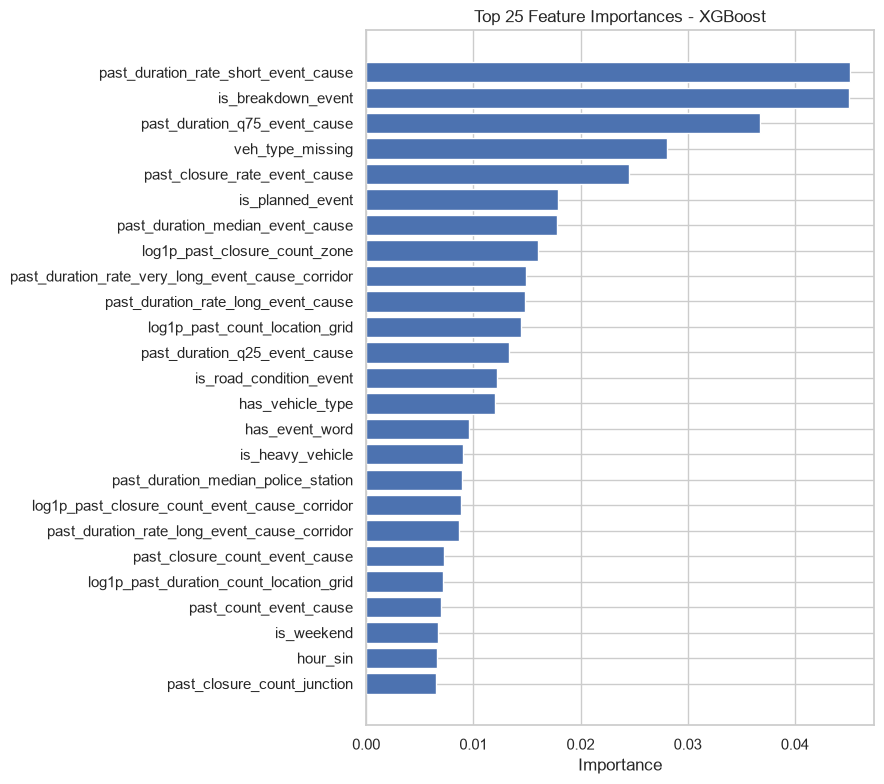

In [15]:
if hasattr(main_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': main_model.feature_importances_,
    }).sort_values('importance', ascending=False)
else:
    feature_importance = pd.DataFrame(columns=['feature', 'importance'])

display(feature_importance.head(30))

plt.figure(figsize=(9, 8))
top_features = feature_importance.head(25).iloc[::-1]
plt.barh(top_features['feature'], top_features['importance'])
plt.title(f'Top 25 Feature Importances - {model_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 14. Optional Permutation Importance

This is slower, but often more trustworthy than built-in tree importance. Run it when you want a deeper model check.

In [16]:
RUN_PERMUTATION_IMPORTANCE = False

if RUN_PERMUTATION_IMPORTANCE:
    perm = permutation_importance(
        main_model,
        X_val,
        y_val,
        scoring='f1_macro',
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    perm_df = pd.DataFrame({
        'feature': X_val.columns,
        'importance_mean': perm.importances_mean,
        'importance_std': perm.importances_std,
    }).sort_values('importance_mean', ascending=False)
    display(perm_df.head(30))
else:
    print('Skipped. Set RUN_PERMUTATION_IMPORTANCE = True to run this check.')

Skipped. Set RUN_PERMUTATION_IMPORTANCE = True to run this check.


## 15. Save Artifacts

This saves the model, label mapping, metrics, feature importances, and test predictions.

In [17]:
MODELS_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

model_artifact = {
    'model': main_model,
    'model_name': model_name,
    'feature_cols': feature_cols,
    'label_encoder': label_encoder,
    'label_mapping': label_mapping,
    'inverse_label_mapping': inverse_label_mapping,
}

model_path = MODELS_DIR / 'model2_v1_duration_band_model.pkl'
predictions_path = OUTPUTS_DIR / 'model2_v1_duration_band_predictions.csv'
importance_path = OUTPUTS_DIR / 'model2_v1_duration_band_feature_importance.csv'
metrics_path = OUTPUTS_DIR / 'model2_v1_duration_band_metrics.json'

joblib.dump(model_artifact, model_path)
predictions_df.to_csv(predictions_path, index=False)
feature_importance.to_csv(importance_path, index=False)

metrics = {
    'model_name': model_name,
    'test_accuracy': float(test_accuracy),
    'test_balanced_accuracy': float(test_bal_acc),
    'test_macro_f1': float(test_macro_f1),
    'test_weighted_f1': float(test_weighted_f1),
    'label_mapping': {k: int(v) for k, v in label_mapping.items()},
    'train_rows': int(len(X_train)),
    'validation_rows': int(len(X_val)),
    'test_rows': int(len(X_test)),
    'feature_count': int(X.shape[1]),
    #'used_model1_probability': model1_feature_name in X.columns,
}

with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved model:', model_path)
print('Saved predictions:', predictions_path)
print('Saved feature importance:', importance_path)
print('Saved metrics:', metrics_path)

Saved model: D:\Python\Gridlock\Phase 2\theme 2\models\model2_v1_duration_band_model.pkl
Saved predictions: D:\Python\Gridlock\Phase 2\theme 2\outputs\model2_v1_duration_band_predictions.csv
Saved feature importance: D:\Python\Gridlock\Phase 2\theme 2\outputs\model2_v1_duration_band_feature_importance.csv
Saved metrics: D:\Python\Gridlock\Phase 2\theme 2\outputs\model2_v1_duration_band_metrics.json


## 16. Single-Event Prediction Helper

Use this to test one row from the dataset and inspect the predicted duration band plus probabilities.

In [18]:
def predict_duration_band(row_or_df):
    if isinstance(row_or_df, pd.Series):
        event_df = row_or_df.to_frame().T
    else:
        event_df = row_or_df.copy()

    event_X = event_df[feature_cols].copy()
    for col in event_X.columns:
        event_X[col] = pd.to_numeric(event_X[col], errors='coerce')
    event_X = event_X.replace([np.inf, -np.inf], np.nan)
    event_X = event_X.fillna(X_train.median(numeric_only=True)).fillna(0)

    proba = main_model.predict_proba(event_X)
    pred = main_model.predict(event_X)

    result = pd.DataFrame(proba, columns=[f'prob_{label}' for label in label_encoder.classes_])
    result.insert(0, 'predicted_duration_band', label_encoder.inverse_transform(pred))
    result.insert(1, 'prediction_confidence', proba.max(axis=1))
    return result

sample_row = model_df.iloc[[0]].copy()
print('Actual duration band:', sample_row[target_col].iloc[0])
display(predict_duration_band(sample_row))

Actual duration band: medium


,predicted_duration_band,prediction_confidence,prob_long,prob_medium,prob_short,prob_very_long
0,medium,0.744635,0.010427,0.744635,0.024358,0.220581


## 17. Final Validation Summary

Use this cell at the end to print the numbers that belong in the project report.

In [19]:
print('=' * 72)
print('MODEL 2: DURATION BAND CLASSIFIER SUMMARY')
print('=' * 72)
print('Dataset:', DATA_PATH.name)
print('Rows used:', len(model_df))
print('Features:', X.shape[1])
print('Model:', model_name)
print('Used Model 1 probability:', model1_feature_name in X.columns)
print('Test Accuracy:', round(test_accuracy, 4))
print('Test Balanced Accuracy:', round(test_bal_acc, 4))
print('Test Macro-F1:', round(test_macro_f1, 4))
print('Test Weighted-F1:', round(test_weighted_f1, 4))
print('\nPer-class metrics:')
display(per_class_metrics)
print('\nArtifacts:')
print('-', model_path)
print('-', predictions_path)
print('-', importance_path)
print('-', metrics_path)
print('=' * 72)

MODEL 2: DURATION BAND CLASSIFIER SUMMARY


AttributeError: 'str' object has no attribute 'name'